In this notebook I compute the **Percent Trips Connected** and **Percent Nodes
Connected** metrics following the methodology of Mekuria, Furth & Nixon (2012),
applied to the Belfast Local Government District.

## Methodology Overview

Two points are said to be *connected* at a given LTS level if there exists a
path between them using only links that do not exceed that level of stress,
and the path does not involve undue detour. The detour criterion requires that
the low-stress path length must not exceed the shortest (all-network) path by
more than **25%**, or for short trips, **0.53 km (0.33 miles)**.

**Percent Trips Connected** is the share of total commuting demand that can be
served by a connected, low-stress route at each LTS threshold, weighted by
Census 2021 commuting flow. **Percent Nodes Connected** is the unweighted
share of OD pairs that satisfy the same criterion.

### Graph Construction — Why Two Data Sources?

The LTS classification in the companion notebook (`belfast_cycle_lts_assessment.ipynb`)
was produced from a pyrosm PBF extract. PBF files are complete snapshots of the
OSM database and preserve all attribute tags (`maxspeed`, `lanes`, `cycleway`,
etc.), yielding more accurate LTS values. However, pyrosm returns edges as
independent line segments **without shared node IDs**, so the resulting graph
is topologically fragmented — in Belfast I observed over 13,000 disconnected
components, with the largest covering only 11% of vertices. This makes routing
and connectivity analysis impossible.

OSMnx, by contrast, extracts a graph with explicit `u`/`v` node identifiers
that guarantee topological connectivity. However, OSMnx pulls only the tags
listed in `ox.settings.useful_tags_way`, so some attributes are lost, leading
to less accurate LTS classification if I were to re-run the pipeline on OSMnx
edges directly.

My solution is a **hybrid approach**: I use the OSMnx graph for topology
(ensuring a single connected component), and transfer the pyrosm-derived LTS
values onto it via spatial join. This achieves a 93.8% match rate; the
remaining ~6% of edges (mostly minor roads absent from the PBF cycling
extract) receive a conservative highway-type fallback.

### Data Sources

| Dataset | Source | Role |
|---|---|---|
| LTS network (pyrosm) | `belfast_cycle_lts_assessment.ipynb` output | Accurate LTS values |
| Road graph (OSMnx) | Overpass API via OSMnx | Topological connectivity |
| OD commuting flows | PCTNI / Census 2021 ODWP01 | Demand (SDZ level) |
| SDZ boundaries | PCTNI `zones_sdz.gpkg` | Spatial units |

### Pipeline

1. Load pyrosm LTS network, SDZ boundaries, and OD data
2. Filter OD pairs to Belfast LGD; exclude intra-zone trips
3. Extract OSMnx graph for Belfast (connected topology)
4. Transfer pyrosm LTS values to OSMnx edges via spatial join
5. Apply highway-type fallback for unmatched edges
6. Build igraph from OSMnx `u`/`v` node IDs
7. Snap SDZ centroids to nearest network node
8. For each LTS threshold (1–4), compute connectivity with detour criterion
9. Calculate Percent Trips Connected and Percent Nodes Connected
10. Visualise and export results

## Environment Setup

In [55]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from shapely.geometry import Point

import igraph as ig
import networkx as nx
import osmnx as ox

ox.settings.use_cache = True
ox.settings.log_console = False

from collections import defaultdict

# Project paths
DATA_DIR = Path('../Data')
OUTPUT_DIR = Path('../Figure')
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Coordinate reference systems
CRS_WGS84 = 'EPSG:4326'
CRS_IG    = 'EPSG:29903'   # Irish Grid — all spatial ops use this

print('Environment ready.')


Environment ready.


## Load Data

### LTS Network (pyrosm)

I load the LTS-classified cycling network produced by the companion notebook.
Each edge has an `lts` column (1–4) and geometry. These LTS values were derived
from a full PBF extract which preserves all OSM tags, so they are more accurate
than what I could obtain from OSMnx alone.

In [56]:
# ── Load the pyrosm LTS-classified network ────────────────────────────────────
edges_lts = gpd.read_parquet(DATA_DIR / 'LTS_Belfast.parquet')
edges_lts = edges_lts.to_crs(CRS_IG)

print(f'Pyrosm edges: {len(edges_lts):,}')
print(f'\nLTS distribution:')
print(edges_lts['lts'].value_counts().sort_index())
print(f'\nNaN LTS: {edges_lts["lts"].isna().sum():,}')


Pyrosm edges: 23,464

LTS distribution:
lts
1.0    9752
2.0    9886
3.0    1528
4.0    2298
Name: count, dtype: int64

NaN LTS: 0


### Study Area — Belfast LGD Zones

In [32]:
# ── SDZ zones ────────────────────────────────────────────────────────────────
sdz_all = gpd.read_file(DATA_DIR / 'zones_sdz.gpkg', engine='pyogrio')
sdz_all = sdz_all.to_crs(CRS_IG)

belfast_sdz = sdz_all[sdz_all['lgd2014_nm'] == 'Belfast'].copy()
belfast_boundary = belfast_sdz.unary_union

# Identify SDZ code column
sdz_code_col = [c for c in belfast_sdz.columns if 'sdz' in c.lower() and 'code' in c.lower()]
sdz_code_col = sdz_code_col[0] if sdz_code_col else belfast_sdz.columns[0]

print(f'Belfast SDZ count: {len(belfast_sdz)}')
print(f'SDZ code column: "{sdz_code_col}"')


Belfast SDZ count: 175
SDZ code column: "sdz2021_cd"


### OD Commuting Data

I use the Census 2021 OD flows from the PCTNI hackathon dataset. This filtered
version retains only `place_of_work_ind_code == 4` (fixed workplace within UK),
with both origin and destination coded at SDZ level.

In [33]:
# ── OD data ──────────────────────────────────────────────────────────────────
od_raw = pd.read_csv(DATA_DIR / 'od_ni_open_filtered.csv')

print(f'Total OD records: {len(od_raw):,}')
print(f'Total commuters: {od_raw["count"].sum():,}')
od_raw.head()


Total OD records: 108,656
Total commuters: 545,210


,area_of_residence_code,workplace_area_code,place_of_work_ind_code,count
0,N21000001,N21000001,4,51
1,N21000001,N21000002,4,3
2,N21000001,N21000003,4,4
3,N21000001,N21000004,4,34
4,N21000001,N21000005,4,28


## OD Data Preparation

The Census 2021 OD commuting flows (ODWP01) are recorded at Super Data Zone
(SDZ) level — the finest geography available in this dataset. Since the OD
codes match `zones_sdz.gpkg` directly, no spatial aggregation is required.
I filter the OD pairs to those with both origin and destination within Belfast
LGD, and exclude intra-zone trips following Mekuria et al. (2012) to limit
the influence of very short trips for which walking is the dominant mode.

In [69]:
# ── Filter OD to Belfast: both origin AND destination within Belfast LGD ────
belfast_sdz_codes = set(belfast_sdz[sdz_code_col].values)

od = od_raw[
    od_raw['area_of_residence_code'].isin(belfast_sdz_codes) &
    od_raw['workplace_area_code'].isin(belfast_sdz_codes)
].copy()

od = od.rename(columns={
    'area_of_residence_code': 'origin_sdz',
    'workplace_area_code': 'dest_sdz',
})

# Exclude intra-zone trips (Mekuria et al. 2012)
od = od[od['origin_sdz'] != od['dest_sdz']].copy()

print(f'Belfast inter-SDZ OD pairs: {len(od):,}')
print(f'Total inter-SDZ commuters: {od["count"].sum():,}')
print(f'Unique origin SDZs: {od["origin_sdz"].nunique()}')
print(f'Unique destination SDZs: {od["dest_sdz"].nunique()}')


Belfast inter-SDZ OD pairs: 13,412
Total inter-SDZ commuters: 68,877
Unique origin SDZs: 175
Unique destination SDZs: 175


## Build Routable Graph

### Extract OSMnx Graph

The pyrosm-extracted network lacks shared node identifiers, producing a
highly fragmented graph (>13,000 disconnected components). To obtain a
topologically connected network, I extract the Belfast road graph via OSMnx
with `network_type='bike'`. OSMnx assigns unique node IDs (`u`, `v`) to each
edge, guaranteeing a single connected component suitable for shortest-path
routing.

In [70]:
# ── Extract Belfast road network via OSMnx ──────────────────────────────────
belfast_poly_4326 = belfast_sdz.to_crs(CRS_WGS84).unary_union

G_osm = ox.graph_from_polygon(
    belfast_poly_4326,
    network_type='bike',
    simplify=True,
    retain_all=False,
)

print(f'OSMnx graph — nodes: {G_osm.number_of_nodes():,}, edges: {G_osm.number_of_edges():,}')
print(f'Connected: {nx.is_connected(G_osm.to_undirected())}')

# Convert to GeoDataFrames
nodes_ox, edges_ox = ox.graph_to_gdfs(G_osm)
edges_ox = edges_ox.reset_index()  # u, v, key become regular columns
edges_ox = edges_ox.to_crs(CRS_IG)
edges_ox['length_m'] = edges_ox.geometry.length

# Flatten list-type columns (OSMnx stores some tags as lists)
for col in edges_ox.columns:
    if edges_ox[col].apply(lambda x: isinstance(x, list)).any():
        edges_ox[col] = edges_ox[col].apply(lambda x: x[0] if isinstance(x, list) else x)

print(f'Edges with u/v topology: {len(edges_ox):,}')


OSMnx graph — nodes: 29,523, edges: 68,927
Connected: True
Edges with u/v topology: 68,927


### Transfer LTS Values via Spatial Join

I now transfer the pyrosm-derived LTS values onto the OSMnx edges. For each
OSMnx edge, I take its midpoint and check whether it falls within a 10 m
buffer of any pyrosm LTS edge. This achieves a ~94% match rate; the remaining
edges receive a conservative highway-type fallback.

In [71]:
from scipy.spatial import cKDTree

# ── Strategy: sample multiple points along each edge, majority vote ─────────

# Prepare pyrosm LTS edges
lts_src = edges_lts[edges_lts['lts'].notna()][['geometry', 'lts']].copy()
lts_src = lts_src.to_crs(CRS_IG)

# Build KD-tree from densely sampled points on pyrosm edges
# Sample a point every ~10m along each pyrosm edge
sample_coords = []
sample_lts = []

for _, row in lts_src.iterrows():
    geom = row.geometry
    length = geom.length
    n_samples = max(int(length / 10), 1)
    for i in range(n_samples):
        frac = (i + 0.5) / n_samples
        pt = geom.interpolate(frac, normalized=True)
        sample_coords.append((pt.x, pt.y))
        sample_lts.append(row['lts'])

sample_coords = np.array(sample_coords)
sample_lts = np.array(sample_lts)
tree = cKDTree(sample_coords)

print(f'Built KD-tree with {len(sample_coords):,} sample points from pyrosm edges')

# For each OSMnx edge, sample multiple points and do majority vote
matched_lts = []

for _, row in edges_ox.iterrows():
    geom = row.geometry
    length = geom.length
    n_query = max(int(length / 10), 3)  # at least 3 sample points
    
    votes = []
    for i in range(n_query):
        frac = (i + 0.5) / n_query
        pt = geom.interpolate(frac, normalized=True)
        dist, idx = tree.query([pt.x, pt.y])
        if dist < 15:  # 15m threshold
            votes.append(sample_lts[idx])
    
    if votes:
        # Majority vote — most common LTS value
        from collections import Counter
        matched_lts.append(Counter(votes).most_common(1)[0][0])
    else:
        matched_lts.append(np.nan)

edges_ox['lts'] = matched_lts

matched = edges_ox['lts'].notna().sum()
print(f'\nMatched: {matched:,} / {len(edges_ox):,} ({matched/len(edges_ox)*100:.1f}%)')
print(f'\nLTS distribution:')
print(edges_ox['lts'].value_counts().sort_index())


Built KD-tree with 215,188 sample points from pyrosm edges

Matched: 68,903 / 68,927 (100.0%)

LTS distribution:
lts
1.0    32960
2.0    22303
3.0     6436
4.0     7204
Name: count, dtype: int64


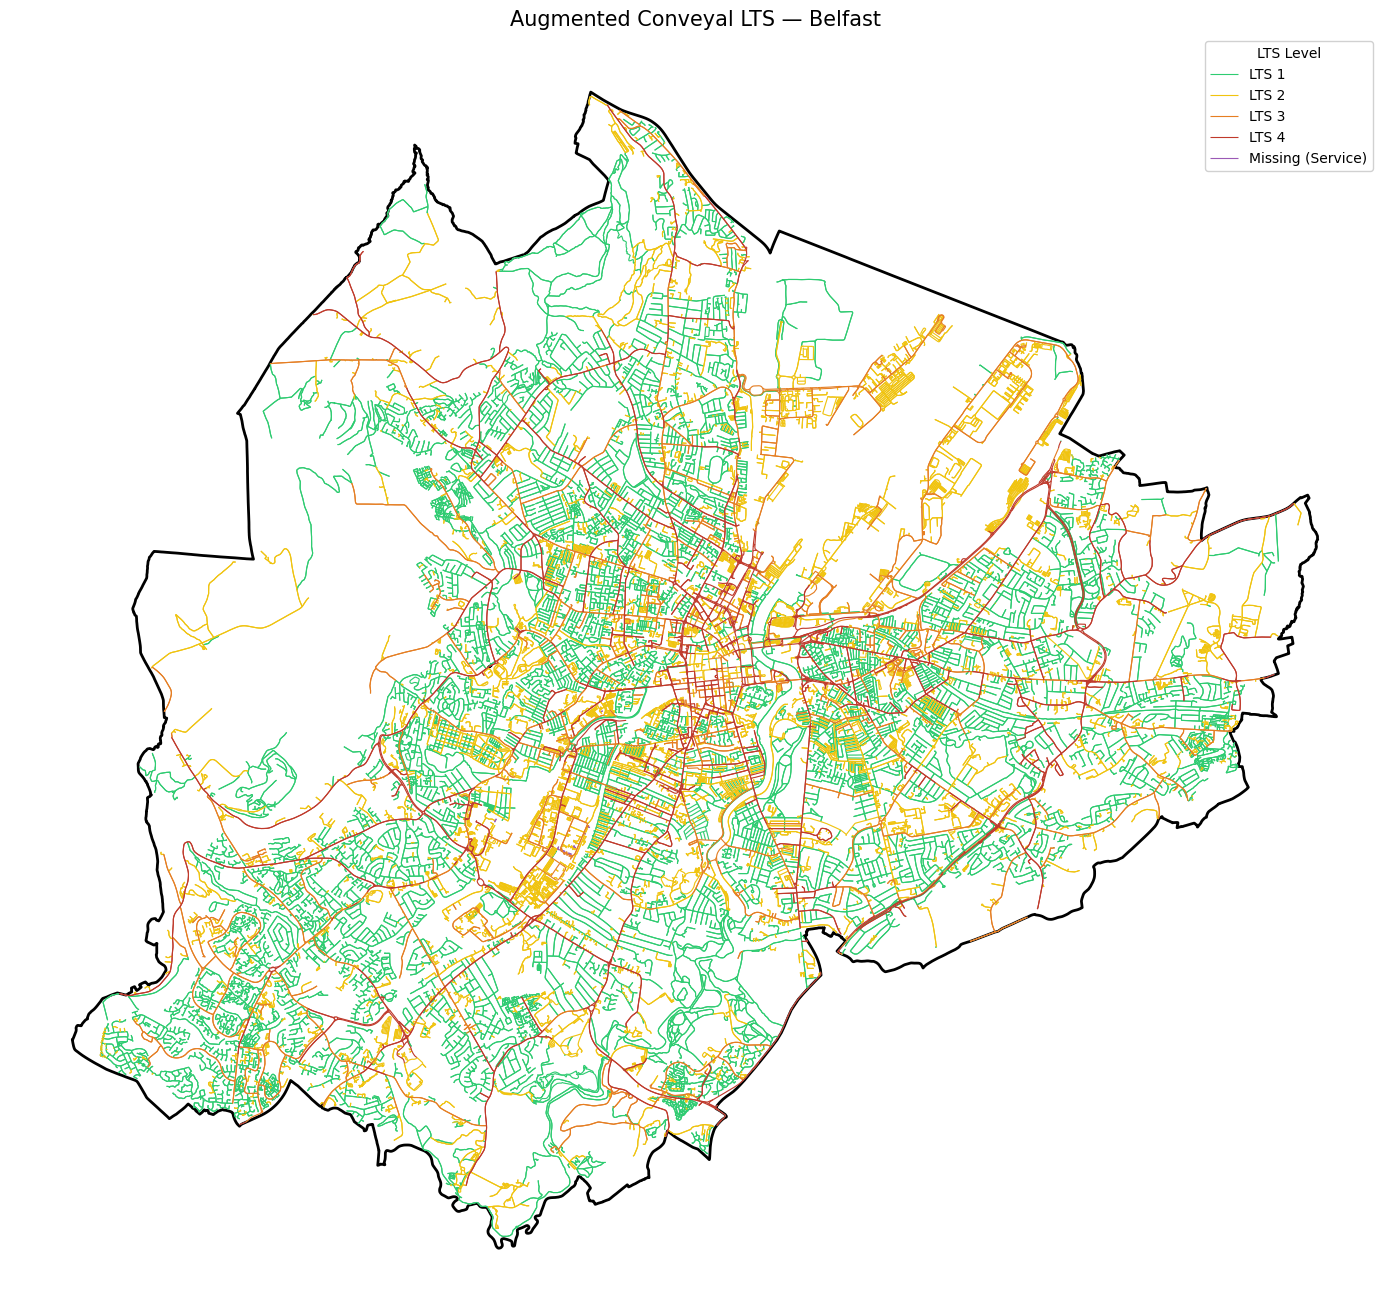

In [74]:
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

plot_gdf = edges_ox

# Define a helper function to format LTS labels for the legend
def lts_label(val):
    if pd.isna(val):
        return 'Missing (Service)'
    return f'LTS {int(val)}'

plot_gdf['lts_status'] = plot_gdf['lts'].apply(lts_label)

# Plot the study area boundary. 
# The CRS parameter here should match the original coordinate system of belfast_boundary.
# If the boundary and edges_ox already share the same CRS, this step can be simplified.
gpd.GeoDataFrame(geometry=[belfast_boundary], crs=plot_gdf.crs).plot(
    ax=ax, facecolor='none', edgecolor='black',
    linewidth=2, linestyle='-', alpha=1, zorder=0
)

# Plot the base road network as a background layer
plot_gdf.plot(ax=ax, color='#eeeeee', linewidth=0.5, zorder=1)

# Define the color mapping for different LTS levels
color_map = {
    'LTS 1': '#2ecc71',
    'LTS 2': '#f1c40f',
    'LTS 3': '#e67e22',
    'LTS 4': '#c0392b',
    'Missing (Service)': '#9b59b6',
}

# Iterate through the color map to plot each LTS level as a separate layer
for status, color in color_map.items():
    subset = plot_gdf[plot_gdf['lts_status'] == status]
    if not subset.empty:
        subset.plot(ax=ax, color=color, linewidth=0.8, label=status,
                    zorder=3 if 'Missing' in status else 2)

# Configure plot titles, legends, and layout
ax.set_title("Augmented Conveyal LTS — Belfast", fontsize=15)
ax.legend(title="LTS Level", loc='upper right', framealpha=0.9)
ax.axis('off')
plt.tight_layout()

# Save the visualization to the specified output directory
plt.savefig(OUTPUT_DIR / 'Belfast_LTS.png', dpi=500, bbox_inches='tight')
plt.show()


### Highway-Type Fallback for Unmatched Edges

The unmatched edges are mostly minor roads (service, residential,
footway) that were absent from the pyrosm cycling extract. I assign them a
conservative LTS based on their highway classification.

In [76]:
# ── Fallback for unmatched edges ────────────────────────────────────────────
FALLBACK_LTS = {
    'cycleway': 1, 'path': 1, 'track': 1, 'living_street': 1,
    'footway': 1, 'pedestrian': 1, 'bridleway': 1,
    'residential': 1, 'service': 2,
    'unclassified': 2, 'tertiary': 2, 'tertiary_link': 2,
    'secondary': 3, 'secondary_link': 3, 'steps': 3,
    'primary': 4, 'primary_link': 4, 'trunk': 4, 'trunk_link': 4,
}

mask = edges_ox['lts'].isna()
edges_ox.loc[mask, 'lts'] = edges_ox.loc[mask, 'highway'].map(FALLBACK_LTS).fillna(3)

print(f'Still unmatched: {edges_ox["lts"].isna().sum()}')
print(f'\nFinal LTS distribution:')
print(edges_ox['lts'].value_counts().sort_index())


Still unmatched: 0

Final LTS distribution:
lts
1.0    32960
2.0    22327
3.0     6436
4.0     7204
Name: count, dtype: int64


### Build igraph Using `u`/`v` Node IDs

I construct the igraph directly from the OSMnx `u` and `v` columns. This
guarantees topological correctness — no coordinate-rounding ambiguity, and
the graph is a single connected component.

In [77]:
# ── Build igraph from u/v node IDs ──────────────────────────────────────────
node_ids = list(set(edges_ox['u'].tolist() + edges_ox['v'].tolist()))
node_id_to_vid = {nid: i for i, nid in enumerate(node_ids)}

edge_list = [
    (node_id_to_vid[row.u], node_id_to_vid[row.v])
    for row in edges_ox.itertuples()
]

G_full = ig.Graph(n=len(node_ids), edges=edge_list, directed=False)
G_full.es['length'] = edges_ox['length_m'].tolist()
G_full.es['lts'] = edges_ox['lts'].astype(int).tolist()

# Store coordinates for centroid snapping (Irish Grid)
nodes_ig = nodes_ox.to_crs(CRS_IG)
coord_to_vid = {
    (nodes_ig.loc[nid, 'geometry'].x, nodes_ig.loc[nid, 'geometry'].y): node_id_to_vid[nid]
    for nid in node_ids
}

comps = G_full.connected_components()
print(f'Connected components: {len(comps)}')
print(f'Vertices: {G_full.vcount():,}, Edges: {G_full.ecount():,}')


Connected components: 1
Vertices: 29,523, Edges: 68,927


## Snap SDZ Centroids to Network

Each SDZ centroid is snapped to the nearest graph vertex using a KD-tree.
This provides the network entry/exit point for routing.

In [78]:
def snap_points_to_graph(points_gdf, coord_to_vid, code_col):
    """
    Snap zone centroids to nearest graph vertex.

    Returns dict: zone_code → vertex_id
    """
    from scipy.spatial import cKDTree

    coords = np.array(list(coord_to_vid.keys()))
    vids = np.array(list(coord_to_vid.values()))
    tree = cKDTree(coords)

    zone_to_vid = {}
    snap_distances = []

    for _, row in points_gdf.iterrows():
        centroid = row.geometry.centroid
        pt = np.array([centroid.x, centroid.y])
        dist, idx = tree.query(pt)
        zone_to_vid[row[code_col]] = int(vids[idx])
        snap_distances.append(dist)

    snap_distances = np.array(snap_distances)
    print(f'Snapped {len(zone_to_vid)} zones to network')
    print(f'Snap distance — median: {np.median(snap_distances):.0f} m, '
          f'max: {np.max(snap_distances):.0f} m, '
          f'mean: {np.mean(snap_distances):.0f} m')

    return zone_to_vid


In [79]:
sdz_to_vid = snap_points_to_graph(belfast_sdz, coord_to_vid, sdz_code_col)

# Check how many OD SDZs are successfully snapped
all_od_sdz = set(od['origin_sdz']) | set(od['dest_sdz'])
snapped = all_od_sdz & set(sdz_to_vid.keys())
print(f'\nOD SDZs in network: {len(snapped)} / {len(all_od_sdz)}')


Snapped 175 zones to network
Snap distance — median: 30 m, max: 591 m, mean: 47 m

OD SDZs in network: 175 / 175


## Connectivity Analysis

### Core Algorithm

For each LTS threshold (1, 2, 3, 4):

1. I extract a **sub-graph** containing only edges with LTS ≤ threshold.
2. For each OD pair, I compute the shortest path on the **sub-graph**.
3. I compare this against the shortest path on the **full graph** (all edges).
4. An OD pair is **connected** if:
   - A path exists on the sub-graph, AND
   - The detour ratio ≤ 1.25 (or absolute detour ≤ 530 m for short trips).

Following Mekuria et al. (2012), I restrict the analysis to OD pairs whose
network distance falls between 0.5 and 6 miles, excluding trips that are
too short (walking-dominant) or too long (unlikely cycling candidates).

In [80]:
# ── Distance thresholds (Mekuria et al. 2012) ─────────────────────────────
DETOUR_RATIO = 1.25       # max 25% longer than shortest path
DETOUR_ABS_M = 530.0      # 0.33 miles in metres — for short trips
MIN_TRIP_M   = 805.0      # 0.5 miles — exclude very short trips
MAX_TRIP_M   = 9_656.0    # 6 miles — exclude very long trips


def compute_connectivity(
    G_full: ig.Graph,
    od_pairs: pd.DataFrame,
    sdz_to_vid: dict,
    lts_thresholds: list[int] = [1, 2, 3, 4],
) -> pd.DataFrame:
    """
    Compute Percent Trips Connected for each LTS threshold.
    """
    print('Computing shortest paths on full network...')

    valid_pairs = od_pairs[
        od_pairs['origin_sdz'].isin(sdz_to_vid) &
        od_pairs['dest_sdz'].isin(sdz_to_vid)
    ].copy()

    valid_pairs['origin_vid'] = valid_pairs['origin_sdz'].map(sdz_to_vid)
    valid_pairs['dest_vid'] = valid_pairs['dest_sdz'].map(sdz_to_vid)
    valid_pairs = valid_pairs[valid_pairs['origin_vid'] != valid_pairs['dest_vid']].copy()

    unique_origins = valid_pairs['origin_vid'].unique().tolist()

    # Full-network shortest paths from each unique origin
    full_sp = {}
    for o_vid in unique_origins:
        full_sp[o_vid] = G_full.shortest_paths(source=o_vid, weights='length')[0]

    valid_pairs['dist_full'] = [
        full_sp[row.origin_vid][row.dest_vid]
        for row in valid_pairs.itertuples()
    ]

    # Filter by distance range (Mekuria: 0.5–6 miles)
    valid_pairs = valid_pairs[
        (valid_pairs['dist_full'] >= MIN_TRIP_M) &
        (valid_pairs['dist_full'] <= MAX_TRIP_M) &
        (valid_pairs['dist_full'] < float('inf'))
    ].copy()

    print(f'Valid OD pairs (0.5–6 miles): {len(valid_pairs):,}')
    print(f'Total demand in range: {valid_pairs["count"].sum():,}')

    # For each LTS threshold, build sub-graph and check connectivity
    for lts_max in lts_thresholds:
        print(f'\n--- LTS ≤ {lts_max} ---')

        sub_edge_ids = [e.index for e in G_full.es if e['lts'] <= lts_max]
        G_sub = G_full.subgraph_edges(sub_edge_ids, delete_vertices=False)
        print(f'  Sub-graph edges: {G_sub.ecount():,} / {G_full.ecount():,}')

        sub_sp = {}
        for o_vid in unique_origins:
            sub_sp[o_vid] = G_sub.shortest_paths(source=o_vid, weights='length')[0]

        col = f'connected_lts{lts_max}'
        connected_flags = []
        for row in valid_pairs.itertuples():
            d_sub = sub_sp[row.origin_vid][row.dest_vid]
            d_full = row.dist_full

            if d_sub == float('inf'):
                connected_flags.append(False)
            else:
                max_allowed = max(d_full * DETOUR_RATIO, d_full + DETOUR_ABS_M)
                connected_flags.append(d_sub <= max_allowed)

        valid_pairs[col] = connected_flags

        n_conn = sum(connected_flags)
        t_conn = valid_pairs.loc[valid_pairs[col], 'count'].sum()
        print(f'  Pairs connected: {n_conn:,} / {len(valid_pairs):,} ({n_conn/len(valid_pairs)*100:.1f}%)')
        print(f'  Trips connected: {t_conn:,} / {valid_pairs["count"].sum():,} ({t_conn/valid_pairs["count"].sum()*100:.1f}%)')

    return valid_pairs


In [81]:
results = compute_connectivity(G_full, od, sdz_to_vid)


Computing shortest paths on full network...
Valid OD pairs (0.5–6 miles): 12,041
Total demand in range: 63,933

--- LTS ≤ 1 ---
  Sub-graph edges: 32,960 / 68,927
  Pairs connected: 33 / 12,041 (0.3%)
  Trips connected: 166 / 63,933 (0.3%)

--- LTS ≤ 2 ---
  Sub-graph edges: 55,287 / 68,927
  Pairs connected: 98 / 12,041 (0.8%)
  Trips connected: 428 / 63,933 (0.7%)

--- LTS ≤ 3 ---
  Sub-graph edges: 61,723 / 68,927
  Pairs connected: 1,000 / 12,041 (8.3%)
  Trips connected: 5,074 / 63,933 (7.9%)

--- LTS ≤ 4 ---
  Sub-graph edges: 68,927 / 68,927
  Pairs connected: 12,041 / 12,041 (100.0%)
  Trips connected: 63,933 / 63,933 (100.0%)


## Summary Metrics

I tabulate the two Mekuria indicators across all four LTS thresholds:

- **Percent Trips Connected**: weighted by commuting flow (demand)
- **Percent Nodes Connected**: unweighted (share of OD pairs)

In [82]:
# ── Build summary table ──────────────────────────────────────────────────────
total_trips = results['count'].sum()
total_pairs = len(results)

summary_rows = []
for lts_max in [1, 2, 3, 4]:
    col = f'connected_lts{lts_max}'
    trips_conn = results.loc[results[col], 'count'].sum()
    pairs_conn = results[col].sum()

    summary_rows.append({
        'LTS Threshold': f'LTS ≤ {lts_max}',
        'Pairs Connected': int(pairs_conn),
        'Total Pairs': total_pairs,
        '% Nodes Connected': round(pairs_conn / total_pairs * 100, 1),
        'Trips Connected': int(trips_conn),
        'Total Trips': int(total_trips),
        '% Trips Connected': round(trips_conn / total_trips * 100, 1),
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))


LTS Threshold  Pairs Connected  Total Pairs  % Nodes Connected  Trips Connected  Total Trips  % Trips Connected
      LTS ≤ 1               33        12041                0.3              166        63933                0.3
      LTS ≤ 2               98        12041                0.8              428        63933                0.7
      LTS ≤ 3             1000        12041                8.3             5074        63933                7.9
      LTS ≤ 4            12041        12041              100.0            63933        63933              100.0


## Visualisation

### Percent Trips Connected & Percent Nodes Connected

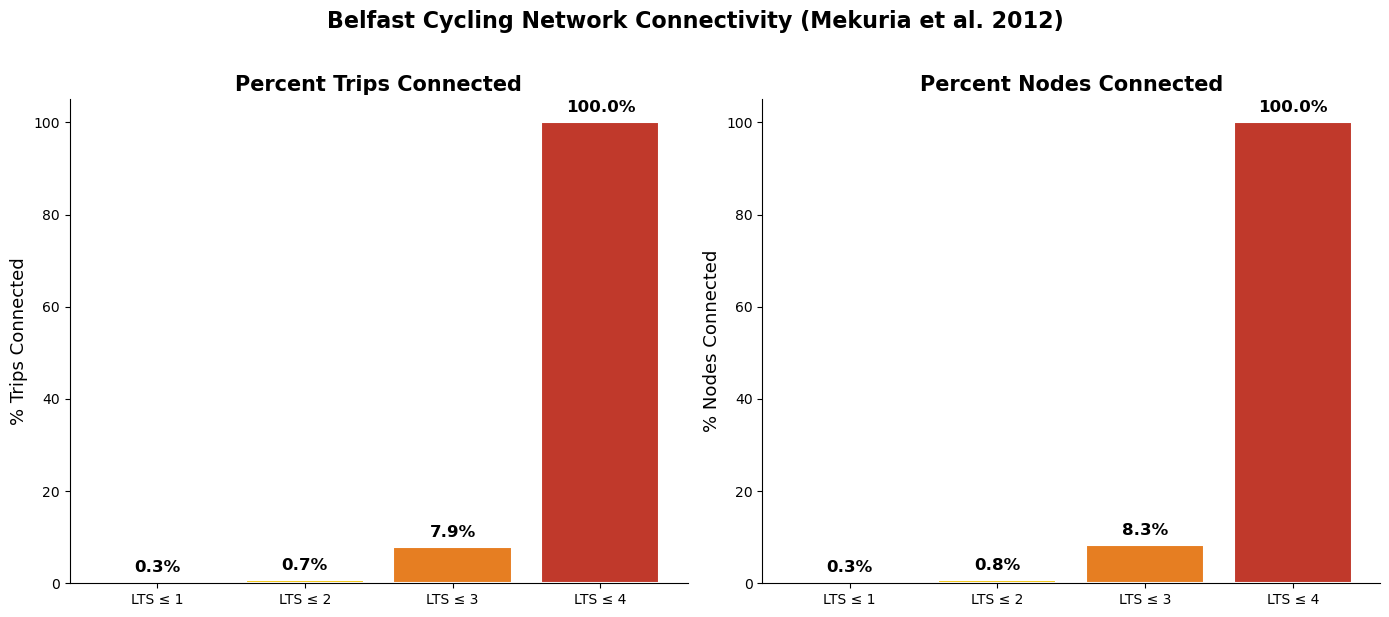

Saved to ..\Figure\belfast_connectivity_metrics.png


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lts_labels = ['LTS ≤ 1', 'LTS ≤ 2', 'LTS ≤ 3', 'LTS ≤ 4']
lts_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b']

# ── Percent Trips Connected ──────────────────────────────────────────────────
ax = axes[0]
pct_trips = summary['% Trips Connected'].values
bars = ax.bar(lts_labels, pct_trips, color=lts_colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('% Trips Connected', fontsize=13)
ax.set_title('Percent Trips Connected', fontsize=15, fontweight='bold')
ax.set_ylim(0, 105)
for bar, val in zip(bars, pct_trips):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# ── Percent Nodes Connected ──────────────────────────────────────────────────
ax = axes[1]
pct_nodes = summary['% Nodes Connected'].values
bars = ax.bar(lts_labels, pct_nodes, color=lts_colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('% Nodes Connected', fontsize=13)
ax.set_title('Percent Nodes Connected', fontsize=15, fontweight='bold')
ax.set_ylim(0, 105)
for bar, val in zip(bars, pct_nodes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Belfast Cycling Network Connectivity (Mekuria et al. 2012)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'belfast_connectivity_metrics.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT_DIR / "belfast_connectivity_metrics.png"}')


### Per-SDZ Connectivity Score

For the dashboard, I compute a per-SDZ metric: what share of outbound
commuting demand from each SDZ is connected at each LTS threshold. This
allows choropleth mapping at SDZ level.

In [84]:
# ── Per-SDZ outbound connectivity score ──────────────────────────────────────
sdz_scores = []

for sdz_code in belfast_sdz[sdz_code_col].values:
    mask = results['origin_sdz'] == sdz_code
    subset = results[mask]
    if len(subset) == 0:
        row = {'sdz_code': sdz_code, 'total_trips': 0}
        for lts_max in [1, 2, 3, 4]:
            row[f'pct_trips_lts{lts_max}'] = np.nan
        sdz_scores.append(row)
        continue

    total = subset['count'].sum()
    row = {'sdz_code': sdz_code, 'total_trips': int(total)}
    for lts_max in [1, 2, 3, 4]:
        col = f'connected_lts{lts_max}'
        conn = subset.loc[subset[col], 'count'].sum()
        row[f'pct_trips_lts{lts_max}'] = round(conn / total * 100, 1) if total > 0 else 0.0
    sdz_scores.append(row)

sdz_scores_df = pd.DataFrame(sdz_scores)
print(sdz_scores_df.describe().round(1))


       total_trips  pct_trips_lts1  pct_trips_lts2  pct_trips_lts3  \
count        175.0           175.0           175.0           175.0   
mean         365.3             0.3             0.7             8.3   
std           97.2             0.8             1.4             9.2   
min          136.0             0.0             0.0             0.0   
25%          292.0             0.0             0.0             0.0   
50%          357.0             0.0             0.0             4.9   
75%          419.5             0.0             0.6            14.2   
max          692.0             4.4             8.4            44.9   

       pct_trips_lts4  
count           175.0  
mean            100.0  
std               0.0  
min             100.0  
25%             100.0  
50%             100.0  
75%             100.0  
max             100.0  


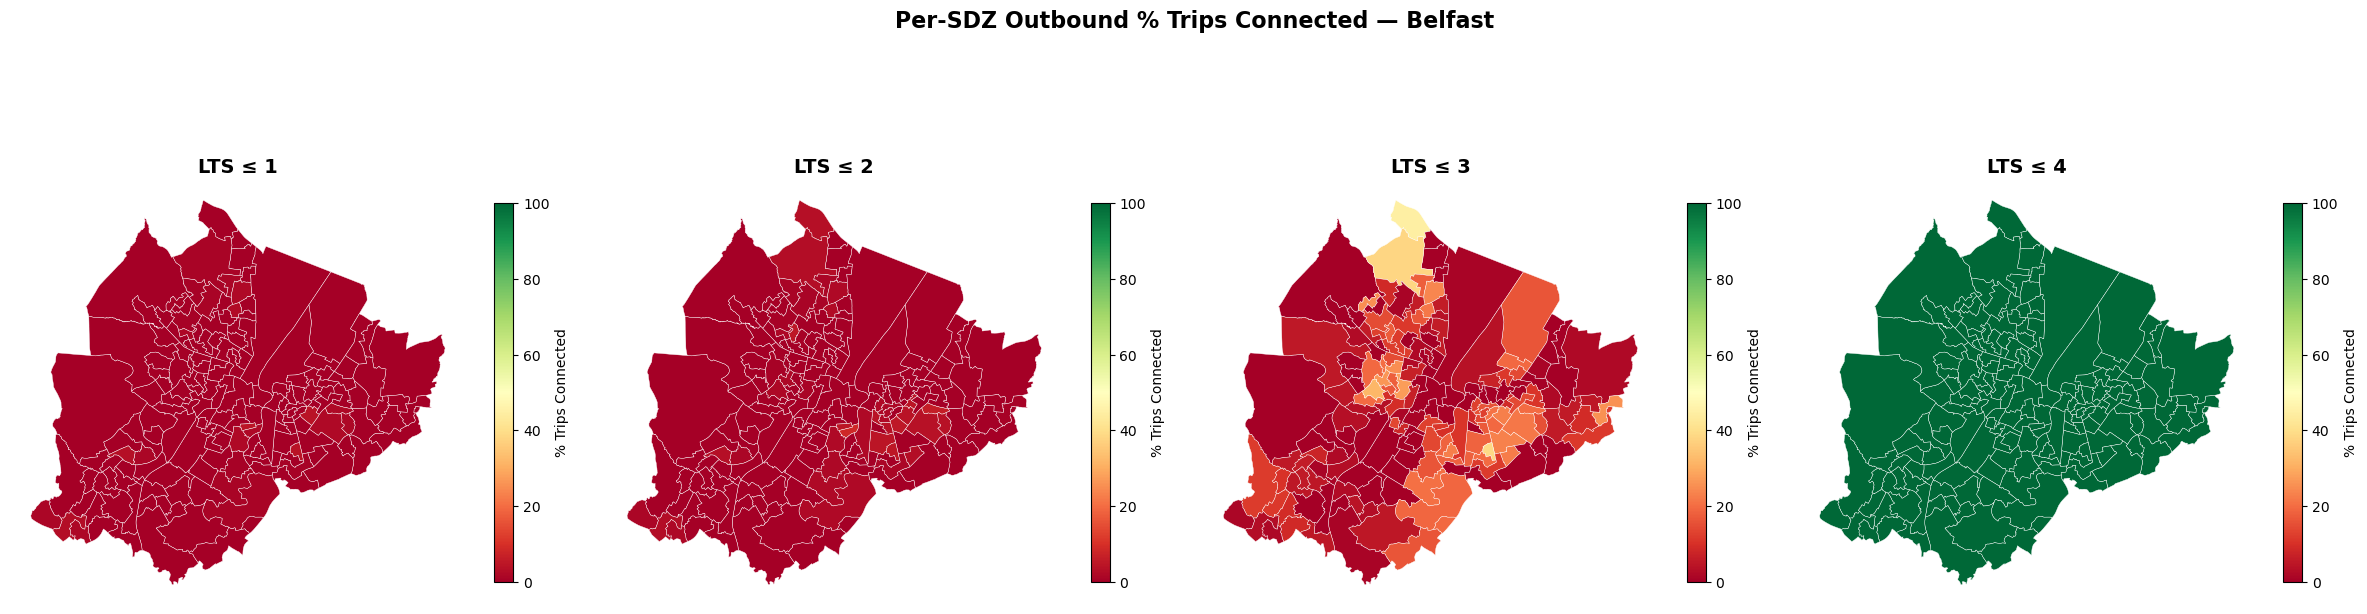

In [85]:
# ── Choropleth: Per-SDZ % Trips Connected ────────────────────────────────────
plot_sdz = belfast_sdz.merge(
    sdz_scores_df, left_on=sdz_code_col, right_on='sdz_code', how='left'
)

fig, axes = plt.subplots(1, 4, figsize=(24, 7))

for i, lts_max in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    col = f'pct_trips_lts{lts_max}'
    plot_sdz.plot(
        column=col, ax=ax, legend=True,
        cmap='RdYlGn', vmin=0, vmax=100,
        edgecolor='white', linewidth=0.3,
        missing_kwds={'color': '#cccccc', 'label': 'No data'},
        legend_kwds={'shrink': 0.6, 'label': '% Trips Connected'}
    )
    ax.set_title(f'LTS ≤ {lts_max}', fontsize=14, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Per-SDZ Outbound % Trips Connected — Belfast',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'belfast_sdz_connectivity_choropleth.png',
            dpi=200, bbox_inches='tight')
plt.show()


### Export Results for Dashboard

I save the per-SDZ scores and OD-level results for the interactive dashboard.

In [93]:
# ── Export ────────────────────────────────────────────────────────────────────
sdz_scores_df.to_csv(DATA_DIR / 'belfast_sdz_connectivity_scores.csv', index=False)
summary.to_csv(DATA_DIR / 'belfast_connectivity_summary.csv', index=False)
results.to_csv(DATA_DIR / 'belfast_od_connectivity_results.csv', index=False)

print('Exported:')
print(f'  {DATA_DIR / "belfast_sdz_connectivity_scores.csv"}')
print(f'  {DATA_DIR / "belfast_connectivity_summary.csv"}')
print(f'  {DATA_DIR / "belfast_od_connectivity_results.csv"}')


Exported:
  ..\Data\belfast_sdz_connectivity_scores.csv
  ..\Data\belfast_connectivity_summary.csv
  ..\Data\belfast_od_connectivity_results.csv


In [94]:
# ── Export all data for the interactive dashboard ────────────────────────────
DASH_DIR = Path('../belfast-cycling-dashboard')
DASH_DIR.mkdir(exist_ok=True)

# 1. LTS network — use pyrosm original (accurate LTS, for map display only)
lts_web = edges_lts[edges_lts['lts'].notna()][['geometry', 'lts']].copy()
lts_web = lts_web.to_crs('EPSG:4326')
lts_web['lts'] = lts_web['lts'].astype(int)
lts_web['geometry'] = lts_web.geometry.simplify(0.0001)
lts_web.to_file(DASH_DIR / 'lts_network.json', driver='GeoJSON')
print(f'1. LTS network: {len(lts_web):,} edges → lts_network.json')

# 2. SDZ boundaries with LTS distribution (for map + bar chart)
lts_dist = pd.read_csv(OUTPUT_DIR / 'belfast_sdz_lts_distribution.csv')
sdz_web = belfast_sdz.merge(lts_dist, on=sdz_code_col, how='left').fillna(0)
sdz_web = sdz_web.to_crs('EPSG:4326')
sdz_web['geometry'] = sdz_web.geometry.simplify(0.0003)
keep = [sdz_code_col, 'sdz2021_nm', 'dea2014_nm', 'lts_1_count', 'lts_2_count', 'lts_3_count', 'lts_4_count', 'geometry']
sdz_web[keep].to_file(DASH_DIR / 'sdz_data.json', driver='GeoJSON')
print(f'2. SDZ zones: {len(sdz_web)} → sdz_data.json')

# 3. OD distances (for detour slider)
import json
od_dist = pd.read_csv(OUTPUT_DIR / 'belfast_od_distances.csv')
for c in ['dist_lts1', 'dist_lts2', 'dist_lts3', 'dist_lts4']:
    od_dist[c] = od_dist[c].replace(float('inf'), -1)
with open(DASH_DIR / 'od_data.json', 'w') as f:
    json.dump(od_dist.to_dict(orient='records'), f, separators=(',', ':'))
print(f'3. OD distances: {len(od_dist):,} pairs → od_data.json')

# 4. Summary table
summary.to_csv(DASH_DIR / 'belfast_connectivity_summary.csv', index=False)
print(f'4. Summary → belfast_connectivity_summary.csv')

print(f'\n── All exported to {DASH_DIR} ──')


1. LTS network: 23,464 edges → lts_network.json
2. SDZ zones: 175 → sdz_data.json
3. OD distances: 12,041 pairs → od_data.json
4. Summary → belfast_connectivity_summary.csv

── All exported to ..\belfast-cycling-dashboard ──


## References

- Mekuria, M. C., Furth, P. G. & Nixon, H. (2012). *Low-Stress Bicycling and
  Network Connectivity*. Mineta Transportation Institute Report 11-19.